# Clustering & engagement prediction with **speaker** features (extended)

This is `clustering_alignment.ipynb` re-run on the **speaker-augmented** feature table
(`all_features_combined_extended.pickle`, produced by section 6 of `additional_features.ipynb`). It keeps the
original flow — PCA of DNN/AU embeddings, target↔reference **alignment** features, then KMeans / GMM /
Agglomerative clustering — but adds the speaker acoustic + text features and asks one concrete question:

> **Do the speaker features improve prediction of the listener's engagement (`majority_label_3`)?**

Because the original cluster→engagement maps were hand-assigned from clip inspection of the *old* clusters,
they no longer apply once features change. So here cluster→label maps are derived **automatically by majority
vote** (descriptive / in-sample), and the trustworthy answer comes from a **cross-validated supervised
comparison** of `X_baseline` (alignment only) vs `X_extended` (+ speaker), reported near the end.

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, accuracy_score, classification_report, confusion_matrix
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import random
import pickle
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import seaborn as sns

random_state = 42
random.seed(random_state)
np.random.seed(random_state)



In [2]:
# --- 1. Load the EXTENDED feature table (original columns + speaker features) ---
with open('./all_features_combined_extended.pickle', 'rb') as f:
    all_features_combined_df = pickle.load(f)

with open('./label_df_3.pickle', 'rb') as f:
    label_df_3 = pickle.load(f)

print(label_df_3['majority_label_3'].value_counts())

# Speaker feature columns (exclude the categorical speaker_id).
SPK_AC_COLS  = [c for c in all_features_combined_df.columns if c.startswith('spk_ac_')]
SPK_TXT_COLS = [c for c in all_features_combined_df.columns if c.startswith('spk_txt_')]
SPK_CTX_COLS = [c for c in all_features_combined_df.columns if c.startswith('spk_ctx_')]
SPEAKER_COLS = ['speaker_overlap_sec', 'spk_has_speaker'] + SPK_AC_COLS + SPK_TXT_COLS + SPK_CTX_COLS
print(f"\n{len(SPEAKER_COLS)} speaker columns; "
      f"segments with an identified speaker: {int(all_features_combined_df['spk_has_speaker'].sum())}"
      f"/{len(all_features_combined_df)}")
all_features_combined_df.head(3)

majority_label_3
Active engagement          50
Intermittent engagement    32
Disengagement              20
Name: count, dtype: int64

37 speaker columns; segments with an identified speaker: 531/549


,segment_id,AU_feature,dnn_feature,manual_feature,AU_feature_ref1,dnn_feature_ref1,manual_feature_ref1,AU_feature_ref2,dnn_feature_ref2,manual_feature_ref2,...,spk_txt_negation_rate,spk_txt_second_person_rate,spk_txt_first_plural_rate,spk_txt_sent_compound,spk_coup_coup_xcorr_max,spk_coup_coup_xcorr_lag,spk_coup_coup_corr0,spk_coup_coup_motion_mean,spk_coup_resp_after_rise,spk_has_coupling
0,20210323-SP07F_clip_378_383,"[0.1441269841269841, 0.3001846627428381, 2.0, ...","[0.034613874, -0.22478016, 0.07269942, -0.3664...","[126.0, 12.609585210300457, 28.444309351049924...","[0.2984126984126984, 0.581175928886822, 3.0, 3...","[0.052595716, 0.06267054, -0.123, -0.41390204,...","[126.0, -23.982031966138386, 25.88700200677383...","[0.1348412698412698, 0.2224328541451883, 6.0, ...","[-0.299179, -0.36308083, -0.21096529, 0.192069...","[126.0, -3.078479217421869, 24.666117899730004...",...,0.095238,0.047619,0.142857,-0.0762,0.157122,1.00,-0.197198,4.502427,-0.298513,True
1,20210323-SP07F_clip_1113_1118,"[0.1441269841269841, 0.3001846627428381, 2.0, ...","[0.061545894, -0.25375453, -0.04545928, -0.193...","[125.0, 8.967601040954058, 26.538118969393903,...","[0.053015873015873, 0.0807590969862327, 0.0, -...","[0.07015944, 0.020164885, -0.05986896, -0.2490...","[126.0, -42.03995220760016, 27.480209132219365...","[0.2984126984126984, 0.581175928886822, 3.0, 3...","[0.027060911, -0.08274244, 0.0400747, 0.069514...","[126.0, -1.0203919666780152, 26.30721485617076...",...,0.000000,0.000000,0.000000,0.0000,NaN,NaN,NaN,NaN,NaN,False
2,20210323-SP07F_clip_1074_1079,"[0.1441269841269841, 0.3001846627428381, 2.0, ...","[-0.009148686, -0.12560014, -0.08919125, -0.21...","[121.0, 16.190503685472198, 26.270694432031604...","[0.1348412698412698, 0.2224328541451883, 6.0, ...","[-0.299179, -0.36308083, -0.21096529, 0.192069...","[126.0, 22.120582578287895, 22.3158813791212, ...","[0.2984126984126984, 0.581175928886822, 3.0, 3...","[0.037613317, -0.005479859, 0.007825111, -0.00...","[126.0, -3.270940913024445, 27.572546816724127...",...,0.076923,0.000000,0.000000,0.5232,0.341366,0.84,0.191980,5.960259,0.042195,True


Original DNN features shape: (1647, 512)
PCA transformed DNN features shape: (1647, 100)


/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: invalid val

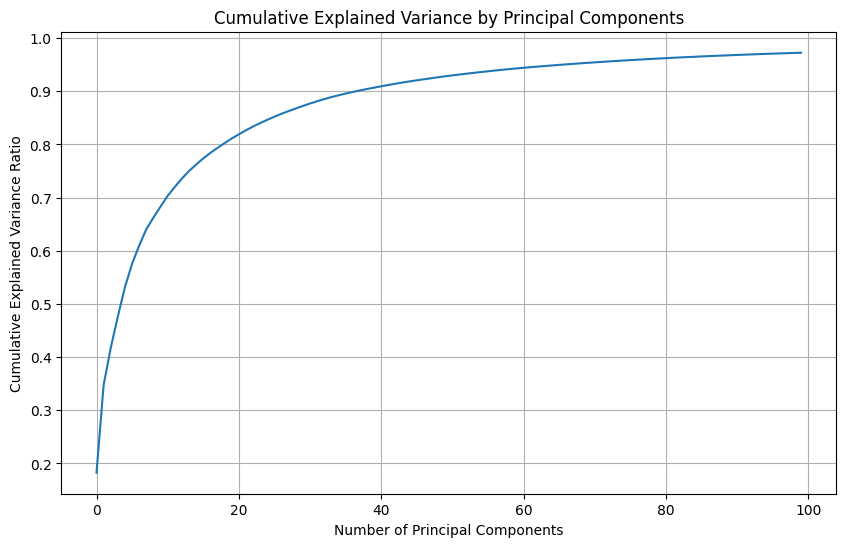

In [3]:
# prompt: apply pca for all_features_combined_df dnn_features

import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# Assuming 'dnn_features' is a column in all_features_combined_df that contains the DNN features
# If it's a separate variable or needs different handling, adjust accordingly.

# Extract the DNN features
dnn_features = all_features_combined_df['dnn_feature'].tolist() +all_features_combined_df['dnn_feature_ref1'].tolist() +all_features_combined_df['dnn_feature_ref2'].tolist() # Convert to list of arrays
dnn_features = np.array(dnn_features) # Convert list of arrays to a single numpy array

# Standardize the data before applying PCA
scaler = StandardScaler()
dnn_features_scaled = scaler.fit_transform(dnn_features)

# Apply PCA
# You can choose the number of components, here we'll keep all for now, or specify a number (e.g., n_components=100)
pca = PCA(100)
dnn_features_pca = pca.fit_transform(dnn_features)

# You can now use dnn_features_pca for further analysis or store it
print("Original DNN features shape:", dnn_features.shape)
print("PCA transformed DNN features shape:", dnn_features_pca.shape)

# Optional: Analyze the explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
# print("Explained variance ratio:", explained_variance_ratio)

# Optional: Plot explained variance to help decide on the number of components
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(explained_variance_ratio))
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Cumulative Explained Variance by Principal Components')
plt.grid(True)
plt.show()

all_features_combined_df['dnn_feature_pca'] = dnn_features_pca.tolist()[:len(all_features_combined_df)]
all_features_combined_df['dnn_feature_pca_ref1'] = dnn_features_pca.tolist()[len(all_features_combined_df):len(all_features_combined_df)*2]
all_features_combined_df['dnn_feature_pca_ref2'] = dnn_features_pca.tolist()[len(all_features_combined_df)*2:]

Original AU features shape: (1647, 85)
PCA transformed AU features shape: (1647, 20)


/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWa

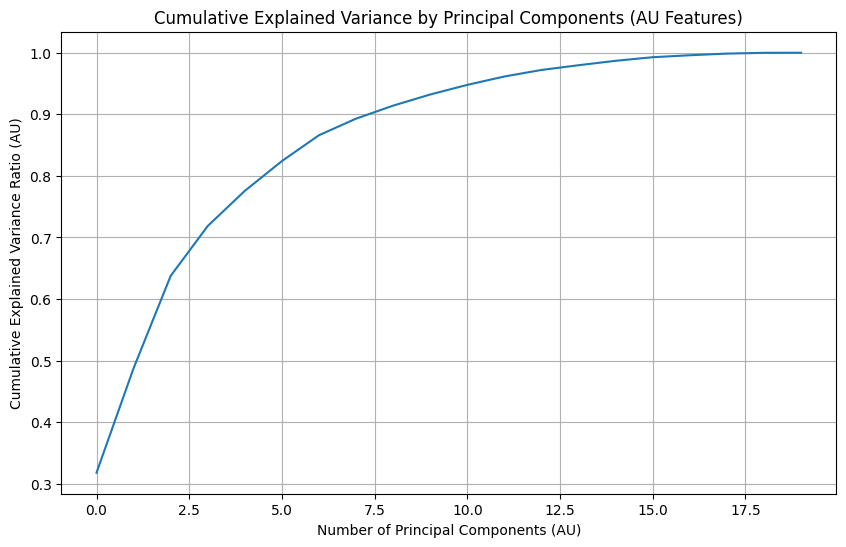

AU PCA features added to DataFrame.


In [4]:
# prompt: apply pca for au features

import matplotlib.pyplot as plt
import numpy as np
# --- Apply PCA for AU features ---

# Extract the AU features
# Assuming 'au_features' and similar columns exist in all_features_combined_df
# You might need to adjust the column names based on your dataframe structure
au_features_cols = ['AU_feature', 'AU_feature_ref1', 'AU_feature_ref2'] # Adjust column names as needed
au_features_list = []
for col in au_features_cols:
    if col in all_features_combined_df.columns:
        # Assuming AU features are stored as lists or arrays in the DataFrame cells
        au_features_list.extend(all_features_combined_df[col].tolist())
    else:
        print(f"Warning: Column '{col}' not found in the DataFrame.")

if not au_features_list:
    print("Error: No AU feature columns found or they are empty.")
else:
    au_features = np.array(au_features_list)

    # Standardize the data before applying PCA
    scaler_au = StandardScaler()
    au_features_scaled = scaler_au.fit_transform(au_features)

    # Apply PCA for AU features
    # You can choose the number of components, e.g., 20 for AU features
    pca_au = PCA(n_components=20) # Adjust n_components as needed
    au_features_pca = pca_au.fit_transform(au_features_scaled)

    # Print shapes
    print("Original AU features shape:", au_features.shape)
    print("PCA transformed AU features shape:", au_features_pca.shape)

    # Optional: Analyze the explained variance ratio for AU features
    explained_variance_ratio_au = pca_au.explained_variance_ratio_
    # print("Explained variance ratio for AU features:", explained_variance_ratio_au)

    # Optional: Plot explained variance for AU features
    plt.figure(figsize=(10, 6))
    plt.plot(np.cumsum(explained_variance_ratio_au))
    plt.xlabel('Number of Principal Components (AU)')
    plt.ylabel('Cumulative Explained Variance Ratio (AU)')
    plt.title('Cumulative Explained Variance by Principal Components (AU Features)')
    plt.grid(True)
    plt.show()

    # Add PCA transformed AU features back to the DataFrame
    # Need to split the combined PCA results back to original reference groups
    num_samples_per_ref = len(all_features_combined_df)
    all_features_combined_df['au_features_pca'] = au_features_pca[:num_samples_per_ref].tolist()
    if len(au_features_cols) > 1:
        all_features_combined_df['au_features_pca_ref1'] = au_features_pca[num_samples_per_ref:num_samples_per_ref*2].tolist()
    if len(au_features_cols) > 2:
        all_features_combined_df['au_features_pca_ref2'] = au_features_pca[num_samples_per_ref*2:].tolist()

    print("AU PCA features added to DataFrame.")

In [5]:
# prompt: calucate alignment_feature that contain cosin similarity between each pari (au_features_pca, au_features_pca_ref1, au_features_pca_ref2) , (dnn_feature_pca, dnn_feature_pca_ref1, dnn_feature_pca_ref2), abs of sub  element wise manual_feature

import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def calculate_cosine_similarity(feature1, feature2):
  """Calculates cosine similarity between two feature vectors."""
  # Ensure features are numpy arrays for calculation
  feature1 = np.array(feature1)
  feature2 = np.array(feature2)

  # Reshape for cosine_similarity if they are 1D
  if feature1.ndim == 1:
      feature1 = feature1.reshape(1, -1)
  if feature2.ndim == 1:
      feature2 = feature2.reshape(1, -1)

  # Handle cases where one of the features might be empty or invalid after processing
  if feature1.size == 0 or feature2.size == 0:
      return np.nan # Return NaN for undefined similarity

  return cosine_similarity(feature1, feature2)[0][0]

# Calculate alignment features
alignment_features = pd.DataFrame()

# Cosine similarity for AU features
if 'au_features_pca' in all_features_combined_df.columns and \
   'au_features_pca_ref1' in all_features_combined_df.columns and \
   'au_features_pca_ref2' in all_features_combined_df.columns:
    alignment_features['au_align_ref1'] = all_features_combined_df.apply(
        lambda row: calculate_cosine_similarity(row['au_features_pca'], row['au_features_pca_ref1']), axis=1
    )
    alignment_features['au_align_ref2'] = all_features_combined_df.apply(
        lambda row: calculate_cosine_similarity(row['au_features_pca'], row['au_features_pca_ref2']), axis=1
    )
    alignment_features['au_align_ref1_ref2'] = all_features_combined_df.apply(
        lambda row: calculate_cosine_similarity(row['au_features_pca_ref1'], row['au_features_pca_ref2']), axis=1
    )

# Cosine similarity for DNN features
if 'dnn_feature_pca' in all_features_combined_df.columns and \
   'dnn_feature_pca_ref1' in all_features_combined_df.columns and \
   'dnn_feature_pca_ref2' in all_features_combined_df.columns:
    alignment_features['dnn_align_ref1'] = all_features_combined_df.apply(
        lambda row: calculate_cosine_similarity(row['dnn_feature_pca'], row['dnn_feature_pca_ref1']), axis=1
    )
    alignment_features['dnn_align_ref2'] = all_features_combined_df.apply(
        lambda row: calculate_cosine_similarity(row['dnn_feature_pca'], row['dnn_feature_pca_ref2']), axis=1
    )
    alignment_features['dnn_align_ref1_ref2'] = all_features_combined_df.apply(
        lambda row: calculate_cosine_similarity(row['dnn_feature_pca_ref1'], row['dnn_feature_pca_ref2']), axis=1
    )

# Absolute difference for manual features
# Assuming 'manual_feature', 'manual_feature_ref1', 'manual_feature_ref2' exist and are numeric or lists of numerics
manual_features_cols = ['manual_feature', 'manual_feature_ref1', 'manual_feature_ref2'] # Adjust as needed

if all(col in all_features_combined_df.columns for col in manual_features_cols):
    alignment_features['manual_diff_ref1'] = all_features_combined_df.apply(
        lambda row: np.abs(np.array(row['manual_feature']) - np.array(row['manual_feature_ref1'])), axis=1
    )
    alignment_features['manual_diff_ref2'] = all_features_combined_df.apply(
        lambda row: np.abs(np.array(row['manual_feature']) - np.array(row['manual_feature_ref2'])), axis=1
    )
    alignment_features['manual_diff_ref1_ref2'] = all_features_combined_df.apply(
        lambda row: np.abs(np.array(row['manual_feature_ref1']) - np.array(row['manual_feature_ref2'])), axis=1
    )

# Display the resulting alignment features dataframe
print("\nAlignment Features DataFrame:")
print(alignment_features.columns)

# You can merge this alignment_features dataframe back to your main dataframe if needed
all_features_combined_df = pd.concat([all_features_combined_df, alignment_features], axis=1)
print("\nCombined DataFrame with Alignment Features:")
all_features_combined_df.head()


Alignment Features DataFrame:
Index(['au_align_ref1', 'au_align_ref2', 'au_align_ref1_ref2',
       'dnn_align_ref1', 'dnn_align_ref2', 'dnn_align_ref1_ref2',
       'manual_diff_ref1', 'manual_diff_ref2', 'manual_diff_ref1_ref2'],
      dtype='object')

Combined DataFrame with Alignment Features:


,segment_id,AU_feature,dnn_feature,manual_feature,AU_feature_ref1,dnn_feature_ref1,manual_feature_ref1,AU_feature_ref2,dnn_feature_ref2,manual_feature_ref2,...,au_features_pca_ref2,au_align_ref1,au_align_ref2,au_align_ref1_ref2,dnn_align_ref1,dnn_align_ref2,dnn_align_ref1_ref2,manual_diff_ref1,manual_diff_ref2,manual_diff_ref1_ref2
0,20210323-SP07F_clip_378_383,"[0.1441269841269841, 0.3001846627428381, 2.0, ...","[0.034613874, -0.22478016, 0.07269942, -0.3664...","[126.0, 12.609585210300457, 28.444309351049924...","[0.2984126984126984, 0.581175928886822, 3.0, 3...","[0.052595716, 0.06267054, -0.123, -0.41390204,...","[126.0, -23.982031966138386, 25.88700200677383...","[0.1348412698412698, 0.2224328541451883, 6.0, ...","[-0.299179, -0.36308083, -0.21096529, 0.192069...","[126.0, -3.078479217421869, 24.666117899730004...",...,"[-5.155540126223967, 6.4673807413762825, -6.19...",0.410391,0.339832,0.076046,0.205783,-0.205084,-0.244327,"[0.0, 36.591617176438845, 2.55730734427609, 0....","[0.0, 15.688064427722326, 3.7781914513199197, ...","[0.0, 20.903552748716518, 1.2208841070438297, ..."
1,20210323-SP07F_clip_1113_1118,"[0.1441269841269841, 0.3001846627428381, 2.0, ...","[0.061545894, -0.25375453, -0.04545928, -0.193...","[125.0, 8.967601040954058, 26.538118969393903,...","[0.053015873015873, 0.0807590969862327, 0.0, -...","[0.07015944, 0.020164885, -0.05986896, -0.2490...","[126.0, -42.03995220760016, 27.480209132219365...","[0.2984126984126984, 0.581175928886822, 3.0, 3...","[0.027060911, -0.08274244, 0.0400747, 0.069514...","[126.0, -1.0203919666780152, 26.30721485617076...",...,"[-8.308350690728707, 1.3934146058456987, 3.265...",0.080184,0.410391,-0.126677,0.195924,-0.077700,-0.201347,"[1.0, 51.00755324855422, 0.9420901628254619, 3...","[1.0, 9.987993007632074, 0.23090411322313642, ...","[0.0, 41.01956024092215, 1.1729942760485983, 3..."
2,20210323-SP07F_clip_1074_1079,"[0.1441269841269841, 0.3001846627428381, 2.0, ...","[-0.009148686, -0.12560014, -0.08919125, -0.21...","[121.0, 16.190503685472198, 26.270694432031604...","[0.1348412698412698, 0.2224328541451883, 6.0, ...","[-0.299179, -0.36308083, -0.21096529, 0.192069...","[126.0, 22.120582578287895, 22.3158813791212, ...","[0.2984126984126984, 0.581175928886822, 3.0, 3...","[0.037613317, -0.005479859, 0.007825111, -0.00...","[126.0, -3.270940913024445, 27.572546816724127...",...,"[-8.308350690728707, 1.3934146058456987, 3.265...",0.339832,0.410391,0.076046,-0.184232,0.141752,0.169169,"[5.0, 5.930078892815697, 3.954813052910403, 10...","[5.0, 19.46144459849664, 1.3018523846925234, 3...","[0.0, 25.39152349131234, 5.256665437602926, 34..."
3,20210323-SP07F_clip_1182_1187,"[0.1441269841269841, 0.3001846627428381, 2.0, ...","[-0.041140895, -0.088186085, 0.0039451574, -0....","[89.0, 4.982063863359799, 30.799108675192933, ...","[0.1348412698412698, 0.2224328541451883, 6.0, ...","[-0.299179, -0.36308083, -0.21096529, 0.192069...","[126.0, 17.31989267131847, 23.09387887171484, ...","[0.2984126984126984, 0.581175928886822, 3.0, 3...","[0.15345049, 0.123038046, -0.33340588, -0.4496...","[126.0, 6.043316631352067, 23.236435152206642,...",...,"[-8.308350690728707, 1.3934146058456987, 3.265...",0.339832,0.410391,0.076046,-0.181620,0.198326,-0.260443,"[37.0, 12.337828807958672, 7.705229803478094, ...","[37.0, 1.0612527679922685, 7.562673522986291, ...","[0.0, 11.276576039966404, 0.14255628049180302,..."
4,20210323-SP07F_clip_255_260,"[0.1441269841269841, 0.3001846627428381, 2.0, ...","[-0.017098123, -0.22169487, 0.061171174, -0.33...","[122.0, 12.994270436686323, 28.811799580626968...","[0.088015873015873, 0.1128752928945557, 0.0, -...","[-0.018141264, -0.13290454, 0.06462509, 0.2290...","[126.0, 46.44568364985898, 36.5801491866292, 1...","[0.2984126984126984, 0.581175928886822, 3.0, 3...","[0.102719806, 0.10402108, -0.085270084, -0.421...","[126.0, -18.488218431374484, 27.66351393040864...",...,"[-8.308350690728707, 1.3934146058456987, 3.265...",0.491463,0.410391,0.271017,0.040690,0.2634

In [6]:
print(f"Total segments: {len(all_features_combined_df)}")
print(f"Labeled segments (held-out test): {len(label_df_3)}")

# --- 2. Split: train (unlabeled, for clustering) vs test (labeled) ---
test_segment_ids = label_df_3['segment_id'].unique()
train_df = all_features_combined_df[~all_features_combined_df['segment_id'].isin(test_segment_ids)].copy().reset_index(drop=True)
test_df  = all_features_combined_df[ all_features_combined_df['segment_id'].isin(test_segment_ids)].copy().reset_index(drop=True)
print(f"train (clustering): {len(train_df)} | test (labeled): {len(test_df)}")

# --- 3. Expand list/array feature columns into a numeric matrix (original helper) ---
def extract_and_combine_features(df, feature_cols):
    feature_dfs = []
    for col in feature_cols:
        expanded = pd.DataFrame(df[col].tolist(), index=df.index).add_prefix(f'{col}_')
        feature_dfs.append(expanded)
    combined = pd.concat(feature_dfs, axis=1)
    return combined.apply(pd.to_numeric, errors='coerce').fillna(0)

# Alignment / PCA / manual feature set == the ORIGINAL clustering_alignment feature set (baseline).
target_feature_columns = ['au_features_pca', 'dnn_feature_pca', 'manual_feature'] + [
    'au_align_ref1', 'au_align_ref2', 'au_align_ref1_ref2',
    'dnn_align_ref1', 'dnn_align_ref2', 'dnn_align_ref1_ref2',
    'manual_diff_ref1', 'manual_diff_ref2', 'manual_diff_ref1_ref2']

def get_segments_for_manual_labeling(df_with_segment_ids, cluster_labels, n_segments_per_cluster=3):
    df_with_segment_ids = df_with_segment_ids.copy()
    df_with_segment_ids['cluster'] = cluster_labels
    out = {}
    for cid in sorted(df_with_segment_ids['cluster'].unique()):
        seg = df_with_segment_ids[df_with_segment_ids['cluster'] == cid]['segment_id']
        out[cid] = seg.sample(min(n_segments_per_cluster, len(seg)), random_state=42).tolist()
    return out

X_train_base = extract_and_combine_features(train_df, target_feature_columns)
print("X_train_base:", X_train_base.shape)

Total segments: 549
Labeled segments (held-out test): 102
train (clustering): 460 | test (labeled): 89
X_train_base: (460, 310)


In [7]:
# --- 3b. Speaker feature block: median-impute acoustic NaNs (silent segments), 0/1 flag ---
spk_medians = train_df[SPK_AC_COLS].median(numeric_only=True)   # impute with TRAIN medians (no leakage)

def speaker_block(df):
    blk = df[SPEAKER_COLS].copy()
    blk['spk_has_speaker'] = blk['spk_has_speaker'].astype(float)
    blk[SPK_AC_COLS] = blk[SPK_AC_COLS].fillna(spk_medians)
    return blk.apply(pd.to_numeric, errors='coerce').fillna(0.0)

spk_train = speaker_block(train_df)

# Baseline (alignment only) vs Extended (+ speaker) feature matrices for the clustering (training) set
X_train_base_df = X_train_base
X_train_ext_df  = pd.concat([X_train_base, spk_train], axis=1)

scaler_base = StandardScaler().fit(X_train_base_df)
scaler      = StandardScaler().fit(X_train_ext_df)     # `scaler` = extended (used by downstream cells)
X_train_base_scaled = scaler_base.transform(X_train_base_df)
X_train_scaled      = scaler.transform(X_train_ext_df)  # downstream clustering uses the EXTENDED matrix

print(f"X_baseline: {X_train_base_df.shape}  ->  X_extended: {X_train_ext_df.shape}  "
      f"(+{X_train_ext_df.shape[1] - X_train_base_df.shape[1]} speaker cols)")

X_baseline: (460, 310)  ->  X_extended: (460, 347)  (+37 speaker cols)


In [8]:
# prompt: write python function to convert 20211007-SP07F_clip_2652_2657  to /content/drive/MyDrive/filtered_clips/20211007-SP07F/clip_2652_2657.mp4

def segment_id_to_filepath(segment_id):
  """
  Converts a segment ID string to a file path in Google Drive.

  Args:
    segment_id: The input segment ID string (e.g., '20211007-SP07F_clip_2652_2657').

  Returns:
    The corresponding file path string (e.g., '/content/drive/MyDrive/filtered_clips/20211007-SP07F/clip_2652_2657.mp4').
  """
  parts = segment_id.split('_')
  date_subject = parts[0]
  clip_name = '_'.join(parts[1:])
  filepath = f"/content/drive/MyDrive/filtered_clips/{date_subject}/{clip_name}.mp4"
  return filepath

# Example usage:
segment_id = '20211007-SP07F_clip_2652_2657'
filepath = segment_id_to_filepath(segment_id)
filepath

'/content/drive/MyDrive/filtered_clips/20211007-SP07F/clip_2652_2657.mp4'

In [9]:
# --- 5. K-Means Clustering ---
print("\n--- K-Means Clustering ---")
silhouette_scores = []
davies_bouldin_scores = []
k_range = range(3, 12) # Test k from 2 to 6 clusters (adjust as needed)
for k_val in k_range:
    kmeans = KMeans(n_clusters=k_val, random_state=42, n_init='auto')
    cluster_labels_k = kmeans.fit_predict(X_train_scaled)
    silhouette_avg = silhouette_score(X_train_scaled, cluster_labels_k)
    db_score = davies_bouldin_score(X_train_scaled, cluster_labels_k)
    silhouette_scores.append(silhouette_avg)
    davies_bouldin_scores.append(db_score)
    print(f"For k={k_val}, Silhouette Score: {silhouette_avg:.4f}, Davies-Bouldin Score: {db_score:.4f}")

# Choose best k (e.g., highest silhouette score or lowest Davies-Bouldin)
# For this example, let's say you inspect the scores and choose one.
# Or, automatically:
best_k_silhouette = k_range[np.argmax(silhouette_scores)]
best_k_db = k_range[np.argmin(davies_bouldin_scores)]
print(f"Suggested k by Silhouette Score: {best_k_silhouette}")
print(f"Suggested k by Davies-Bouldin Score: {best_k_db}")

# You need to choose a final k. Let's assume you choose 3 for this example.
# Or you can use one of the 'best_k' values programmatically.
# For instance, if label_df_3 implies 3 categories:




--- K-Means Clustering ---
For k=3, Silhouette Score: 0.0719, Davies-Bouldin Score: 4.2151
For k=4, Silhouette Score: 0.1026, Davies-Bouldin Score: 3.4508
For k=5, Silhouette Score: 0.0242, Davies-Bouldin Score: 3.9893
For k=6, Silhouette Score: 0.0132, Davies-Bouldin Score: 4.1737
For k=7, Silhouette Score: 0.0212, Davies-Bouldin Score: 3.8764
For k=8, Silhouette Score: 0.0150, Davies-Bouldin Score: 3.8782
For k=9, Silhouette Score: 0.0178, Davies-Bouldin Score: 3.7403
For k=10, Silhouette Score: 0.0121, Davies-Bouldin Score: 3.6011
For k=11, Silhouette Score: 0.0203, Davies-Bouldin Score: 3.6430
Suggested k by Silhouette Score: 4
Suggested k by Davies-Bouldin Score: 4


/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/ducanh/miniconda3/envs/

In [10]:
# Auto-pick k by silhouette (was hardcoded final_k_kmeans=11 in the original).
# final_k_kmeans = int(best_k_silhouette)
final_k_kmeans = 11
print(f"Using k={final_k_kmeans} for K-Means (best silhouette).")
kmeans_final = KMeans(n_clusters=final_k_kmeans, random_state=42, n_init='auto')
train_df['kmeans_cluster'] = kmeans_final.fit_predict(X_train_scaled)

Using k=11 for K-Means (best silhouette).


/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [11]:

# --- 6. Gaussian Mixture Models (GMM) ---
print("\n--- Gaussian Mixture Models (GMM) ---")
bic_scores = []
aic_scores = []
n_components_range = range(3, 10) # Test components from 2 to 6

for n_comp in n_components_range:
    gmm = GaussianMixture(n_components=n_comp, random_state=42, covariance_type='full') # 'diag', 'tied', 'spherical' are other options
    gmm.fit(X_train_scaled)
    bic_scores.append(gmm.bic(X_train_scaled))
    aic_scores.append(gmm.aic(X_train_scaled))
    print(f"For n_components={n_comp}, BIC: {bic_scores[-1]:.2f}, AIC: {aic_scores[-1]:.2f}")

# Choose best n_components (e.g., lowest BIC or AIC)
best_n_gmm_bic = n_components_range[np.argmin(bic_scores)]
best_n_gmm_aic = n_components_range[np.argmin(aic_scores)]
print(f"Suggested n_components by BIC: {best_n_gmm_bic}")
print(f"Suggested n_components by AIC: {best_n_gmm_aic}")




--- Gaussian Mixture Models (GMM) ---
For n_components=3, BIC: 645854.16, AIC: -106760.29


For n_components=4, BIC: 1009792.05, AIC: 6304.74


For n_components=5, BIC: 1126902.25, AIC: -127457.92


/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/ducanh/miniconda3/envs/

For n_components=6, BIC: 1172028.57, AIC: -333204.45
For n_components=7, BIC: 1569359.57, AIC: -186746.32


/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


For n_components=8, BIC: 1702108.13, AIC: -304870.62


For n_components=9, BIC: 2056681.40, AIC: -201170.20
Suggested n_components by BIC: 3
Suggested n_components by AIC: 6


/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [12]:
# Auto-pick n_components by AIC (was hardcoded final_n_gmm=5).
final_n_gmm = int(best_n_gmm_aic) 
print(f"Using n_components={final_n_gmm} for GMM (best AIC).")
gmm_final = GaussianMixture(n_components=final_n_gmm, random_state=42, covariance_type='full')
train_df['gmm_cluster'] = gmm_final.fit_predict(X_train_scaled)

Using n_components=6 for GMM (best AIC).


/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b



--- Hierarchical Clustering ---
Note: Dendrogram will be plotted for a sample of 300 segments due to size.


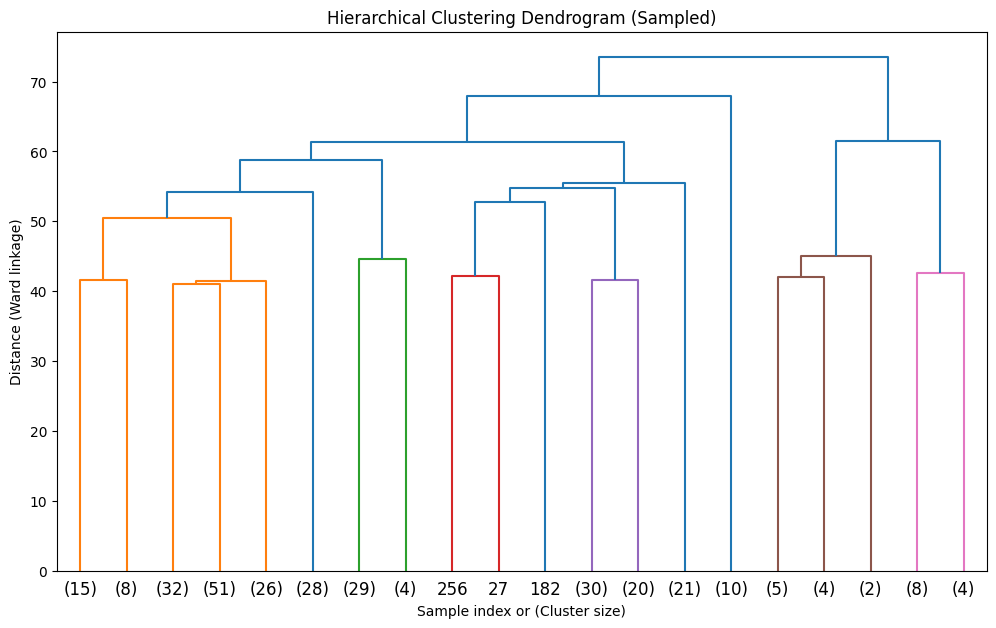


Inspect the dendrogram to decide on the number of clusters for Hierarchical Clustering.


In [13]:

# --- 7. Hierarchical Clustering (Agglomerative) ---
print("\n--- Hierarchical Clustering ---")
# Plotting the dendrogram (can be computationally intensive for large datasets)
# Consider using a subset if X_train_scaled is too large for dendrogram visualization
sample_size_for_dendrogram = min(len(X_train_scaled), 300) # e.g. 150 samples for dendrogram
if len(X_train_scaled) > sample_size_for_dendrogram:
    print(f"Note: Dendrogram will be plotted for a sample of {sample_size_for_dendrogram} segments due to size.")
    sample_indices = np.random.choice(X_train_scaled.shape[0], sample_size_for_dendrogram, replace=False)
    X_train_sample_for_dendrogram = X_train_scaled[sample_indices]
else:
    X_train_sample_for_dendrogram = X_train_scaled

linked = linkage(X_train_sample_for_dendrogram, method='ward') # 'ward', 'complete', 'average'

plt.figure(figsize=(12, 7))
dendrogram(linked,
            orientation='top',
            distance_sort='descending',
            show_leaf_counts=True,
            truncate_mode='lastp', # Show only the last p merged clusters
            p=20 # Show the last 20 merges (adjust for clarity)
          )
plt.title('Hierarchical Clustering Dendrogram (Sampled)')
plt.xlabel("Sample index or (Cluster size)")
plt.ylabel("Distance (Ward linkage)")
plt.show(block=False) # Use block=False if running in a script to continue execution

print("\nInspect the dendrogram to decide on the number of clusters for Hierarchical Clustering.")

# To make the plot visible if script finishes too fast
plt.show()

In [14]:
# Pick k for Agglomerative by silhouette over a small range.
# from sklearn.metrics import silhouette_score as _sil
# _agg_scores = {}
# for _k in range(3, 12):
#     _lab = AgglomerativeClustering(n_clusters=_k, linkage='ward').fit_predict(X_train_scaled)
#     _agg_scores[_k] = _sil(X_train_scaled, _lab)
# final_k_hierarchical = int(max(_agg_scores, key=_agg_scores.get))
# print("Agglomerative silhouette by k:", {k: round(v,3) for k,v in _agg_scores.items()})
final_k_hierarchical = 8
print(f"Using k={final_k_hierarchical} for Hierarchical (best silhouette).")
agg_clustering = AgglomerativeClustering(n_clusters=final_k_hierarchical, linkage='ward')
train_df['hierarchical_cluster'] = agg_clustering.fit_predict(X_train_scaled)

Using k=8 for Hierarchical (best silhouette).


## Manual cluster labeling (parity with the original notebooks)

Mirrors the manual workflow of `clustering.ipynb` / `clustering_alignment.ipynb`: save **3 sample clips per
cluster** for each algorithm, then fill a cluster→engagement map by hand after watching them. Clips are read
from the locally-unzipped `filtered_clips/` (set `CLIPS_BASE`). The automatic majority-vote map below is also
kept, so you can compare manual vs. majority labeling.

In [15]:
import os, shutil

CLIPS_BASE = "./filtered_clips"      # unzipped filtered_clips.zip (folders: <meeting>-<person>/clip_<s>_<e>.mp4)
OUT_ROOT   = "extended_cluster"      # where 3 samples/cluster are copied for viewing

def clip_path(segment_id):
    mp, tail = segment_id.split("_clip_")       # e.g. 20210323-SP01F , 732_737
    return os.path.join(CLIPS_BASE, mp, f"clip_{tail}.mp4")

ALGOS = {"kmean": "kmeans_cluster", "GMM": "gmm_cluster", "HIE": "hierarchical_cluster"}
sample_segments = {}
for algo, col in ALGOS.items():
    samples = get_segments_for_manual_labeling(train_df[["segment_id", col]].copy(),
                                               train_df[col], n_segments_per_cluster=3)
    sample_segments[algo] = samples
    print(f"\n=== {algo}  ({col}) ===")
    n_copied = n_missing = 0
    for cid, segs in samples.items():
        print(f"  Cluster {cid}: {segs}")
        dest = os.path.join(OUT_ROOT, algo, str(cid)); os.makedirs(dest, exist_ok=True)
        for sid in segs:
            src = clip_path(sid)
            if os.path.exists(src):
                shutil.copy(src, os.path.join(dest, os.path.basename(src))); n_copied += 1
            else:
                n_missing += 1
    print(f"  -> copied {n_copied} clips to {OUT_ROOT}/{algo}/ ({n_missing} missing in {CLIPS_BASE})")


=== kmean  (kmeans_cluster) ===
  Cluster 0: ['20210323-SP03M_clip_3_8', '20210616-SP03M_clip_390_395', '20211007-SP03M_clip_3085_3090']
  Cluster 1: ['20210616-SP04F_clip_3_8', '20221209-SP01F_clip_3530_3535', '20221209-SP05F_clip_2710_2715']
  Cluster 2: ['20220610-SP02F_clip_609_614', '20221209-SP07F_clip_745_750', '20211119-SP07F_clip_180_185']
  Cluster 3: ['20221209-SP07F_clip_2530_2535', '20220722-SP02F_clip_651_656', '20220722-SP07F_clip_3378_3383']
  Cluster 4: ['20230310-SP02F_clip_25_30', '20230310-SP06M_clip_1270_1275', '20210616-SP03M_clip_414_419']
  Cluster 5: ['20211007-SP03M_clip_2870_2875', '20220610-SP01F_clip_1758_1763', '20221209-SP04F_clip_705_710']
  Cluster 6: ['20220610-SP07F_clip_762_767', '20220610-SP04F_clip_1896_1901', '20220610-SP07F_clip_765_770']
  Cluster 7: ['20230310-SP01F_clip_885_890', '20230310-SP01F_clip_940_945', '20230310-SP04F_clip_1425_1430']
  Cluster 8: ['20211119-SP01F_clip_1356_1361', '20211007-SP04F_clip_2075_2080', '20210616-SP01F_clip_

In [16]:
# --- FILL THESE IN after watching extended_cluster/<algo>/<cluster>/ ---
# Assign each cluster id one engagement label (leave "" until you decide).
print("Valid labels:", sorted(label_df_3["majority_label_3"].unique()))

kmeans_manual_map       = {i: "" for i in range(final_k_kmeans)}
gmm_manual_map          = {i: "" for i in range(final_n_gmm)}
hierarchical_manual_map = {i: "" for i in range(final_k_hierarchical)}
kmeans_manual_map = {0: "Disengagement", 
                     1: "Active engagement",
   					 2: "Intermittent engagement",
					 3: "Intermittent engagement",}
# Example once filled:  kmeans_manual_map = {0: "Active engagement", 1: "Disengagement", ...}
kmeans_manual_map, gmm_manual_map, hierarchical_manual_map

Valid labels: ['Active engagement', 'Disengagement', 'Intermittent engagement']


({0: 'Disengagement',
  1: 'Active engagement',
  2: 'Intermittent engagement',
  3: 'Intermittent engagement'},
 {0: '', 1: '', 2: '', 3: '', 4: '', 5: ''},
 {0: '', 1: '', 2: '', 3: '', 4: '', 5: '', 6: '', 7: ''})

## Cluster → engagement labels (automatic majority vote)

The original notebook hand-labeled each cluster from representative clips. With new features the clusters
differ, so we instead assign each cluster the **majority true label** of the labeled segments that fall in it.
Note this is *in-sample / optimistic* (the labels used to name clusters are the ones we then score against) —
treat it as descriptive. The rigorous comparison is the cross-validated classifier below.


--- K-Means (auto majority-vote map) ---
Accuracy: 0.5281
                         precision    recall  f1-score   support

      Active engagement       0.52      0.98      0.68        44
          Disengagement       1.00      0.18      0.30        17
Intermittent engagement       0.33      0.04      0.06        28

               accuracy                           0.53        89
              macro avg       0.62      0.40      0.35        89
           weighted avg       0.55      0.53      0.41        89



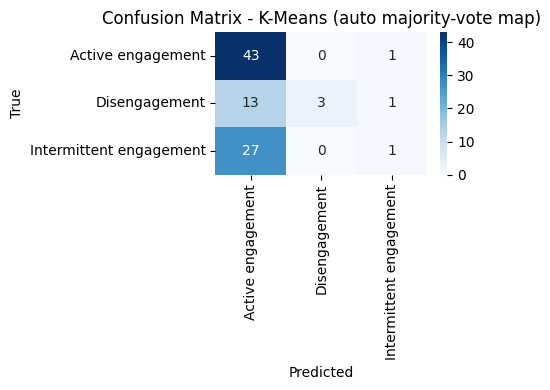


--- GMM (auto majority-vote map) ---
Accuracy: 0.5056
                         precision    recall  f1-score   support

      Active engagement       0.50      1.00      0.67        44
          Disengagement       0.00      0.00      0.00        17
Intermittent engagement       1.00      0.04      0.07        28

               accuracy                           0.51        89
              macro avg       0.50      0.35      0.25        89
           weighted avg       0.56      0.51      0.35        89



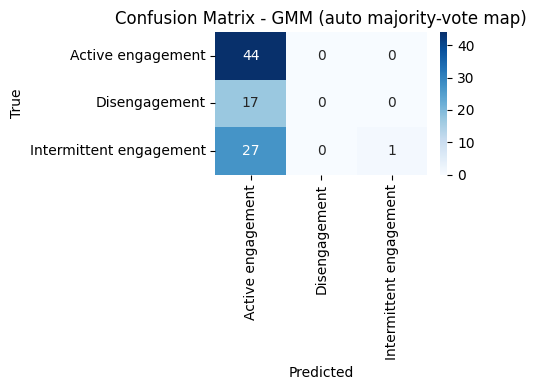


--- Hierarchical (k-NN + auto map) ---
Accuracy: 0.5056
                         precision    recall  f1-score   support

      Active engagement       0.50      0.98      0.66        44
          Disengagement       0.67      0.12      0.20        17
Intermittent engagement       0.00      0.00      0.00        28

               accuracy                           0.51        89
              macro avg       0.39      0.36      0.29        89
           weighted avg       0.37      0.51      0.37        89



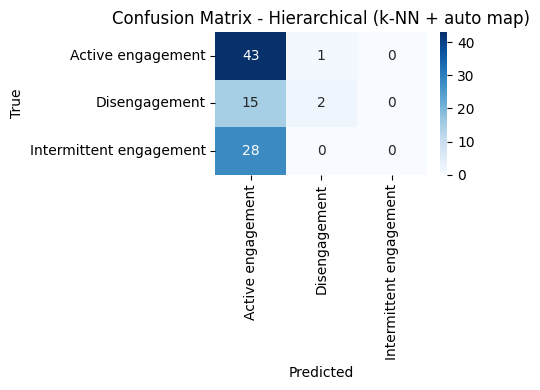

In [17]:
from sklearn.neighbors import KNeighborsClassifier

# Labeled (test) features in the EXTENDED space, scaled with the train-fitted scaler.
X_test_ext_df = pd.concat([extract_and_combine_features(test_df, target_feature_columns),
                           speaker_block(test_df)], axis=1)
X_test_scaled = scaler.transform(X_test_ext_df)
test_eval = test_df.merge(label_df_3[['segment_id','majority_label_3']], on='segment_id', how='left')
y_true_test = test_eval['majority_label_3']
actual_engagement_labels = sorted(label_df_3['majority_label_3'].unique())

def auto_cluster_label_map(cluster_ids, y_true):
    """Majority engagement label per cluster id."""
    s = pd.DataFrame({'c': cluster_ids, 'y': list(y_true)})
    return s.dropna().groupby('c')['y'].agg(lambda x: x.value_counts().idxmax()).to_dict()

def print_evaluation(y_true, y_pred, title, labels_order):
    print(f"\n--- {title} ---")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(classification_report(y_true, y_pred, labels=labels_order, zero_division=0))
    cm = confusion_matrix(y_true, y_pred, labels=labels_order)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_order, yticklabels=labels_order)
    plt.title(f'Confusion Matrix - {title}'); plt.ylabel('True'); plt.xlabel('Predicted'); plt.tight_layout(); plt.show()

# KMeans / GMM: predict labeled segments -> map clusters -> evaluate
for name, model in [("K-Means", kmeans_final), ("GMM", gmm_final)]:
    cl = model.predict(X_test_scaled)
    cmap = auto_cluster_label_map(cl, y_true_test)
    y_pred = pd.Series(cl).map(cmap)
    print_evaluation(y_true_test, y_pred, f"{name} (auto majority-vote map)", actual_engagement_labels)

# Hierarchical: assign labeled segments to train clusters via k-NN, then map
knn = KNeighborsClassifier(n_neighbors=5).fit(X_train_scaled, train_df['hierarchical_cluster'])
cl_h = knn.predict(X_test_scaled)
cmap_h = auto_cluster_label_map(cl_h, y_true_test)
print_evaluation(y_true_test, pd.Series(cl_h).map(cmap_h), "Hierarchical (k-NN + auto map)", actual_engagement_labels)

## Manual-map evaluation (run after filling the maps above)

Maps the held-out labeled segments to engagement via the **hand-filled** maps and compares against the
**majority-vote** maps (macro-F1). Until a map is filled it just reports the majority-vote score.

In [18]:
# from sklearn.metrics import f1_score
# from sklearn.neighbors import KNeighborsClassifier

# def _test_cluster_ids(name):
#     if name == "kmean":
#         return kmeans_final.predict(X_test_scaled)
#     if name == "GMM":
#         return gmm_final.predict(X_test_scaled)
#     # Hierarchical: assign test points to train clusters via k-NN (same as the majority-vote cell)
#     kn = KNeighborsClassifier(n_neighbors=5).fit(X_train_scaled, train_df["hierarchical_cluster"])
#     return kn.predict(X_test_scaled)

# manual_maps = {"kmean": kmeans_manual_map, "GMM": gmm_manual_map, "HIE": hierarchical_manual_map}
# for name in ["kmean", "GMM", "HIE"]:
#     cl = _test_cluster_ids(name)
#     auto_map = auto_cluster_label_map(cl, y_true_test)
#     f1_auto = f1_score(y_true_test, pd.Series(cl).map(auto_map),
#                        average="macro", labels=actual_engagement_labels)
#     mm = manual_maps[name]
#     if (not mm) or any(v == "" for v in mm.values()):
#         print(f"[{name}] manual map not filled — majority-vote macro-F1 = {f1_auto:.3f}. "
#               f"Watch extended_cluster/{name}/, fill the map, and re-run.")
#         continue
#     y_manual = pd.Series(cl).map(mm)
#     print_evaluation(y_true_test, y_manual, f"{name} (manual map)", actual_engagement_labels)
#     f1_manual = f1_score(y_true_test, y_manual, average="macro", labels=actual_engagement_labels)
#     print(f"  {name}: manual macro-F1 = {f1_manual:.3f}  vs  majority-vote macro-F1 = {f1_auto:.3f}")

## Headline: does adding speaker features help? (cross-validated)

Stratified 5-fold CV on the **102 labeled segments**, comparing the alignment-only baseline against the
speaker-extended feature set, for two classifiers. Each fold scales inside a `Pipeline` (no leakage).
Macro-F1 is the primary metric given class imbalance (Active 50 / Intermittent 32 / Disengaged 20).

In [19]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import adjusted_rand_score

# --- Feature groups (split target-only vs alignment vs speaker) ---
# NOTE: target_feature_columns (cell 6) bundles target + alignment together.
# Here we separate them so the BASELINE = target-only, with NO alignment features.
TARGET_ONLY_COLS = ['au_features_pca', 'dnn_feature_pca', 'manual_feature']
ALIGN_COLS = ['au_align_ref1', 'au_align_ref2', 'au_align_ref1_ref2',
              'dnn_align_ref1', 'dnn_align_ref2', 'dnn_align_ref1_ref2',
              'manual_diff_ref1', 'manual_diff_ref2', 'manual_diff_ref1_ref2']

# Labeled-set feature matrices (unscaled; pipeline scales per fold)
Xlab_target = extract_and_combine_features(test_df, TARGET_ONLY_COLS).reset_index(drop=True)
Xlab_align  = extract_and_combine_features(test_df, TARGET_ONLY_COLS + ALIGN_COLS).reset_index(drop=True)
Xlab_ext    = pd.concat([Xlab_align, speaker_block(test_df).reset_index(drop=True)], axis=1)
y  = y_true_test.reset_index(drop=True)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Ordered configurations: target-only baseline -> + alignment -> + speaker
CONFIGS = [
    ("baseline (target-only)", Xlab_target),
    ("+ alignment",            Xlab_align),
    ("+ alignment + speaker",  Xlab_ext),
]

def cv_report(name, clf_factory):
    print(f"\n=== {name} ===")
    for label, X in CONFIGS:
        pipe = make_pipeline(StandardScaler(), clf_factory())
        acc = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
        f1  = cross_val_score(pipe, X, y, cv=cv, scoring='f1_macro')
        print(f"  {label:24s}  acc={acc.mean():.3f}±{acc.std():.3f}   "
              f"macroF1={f1.mean():.3f}±{f1.std():.3f}   (dim={X.shape[1]})")

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

# Majority-class baseline (sanity floor), then the two classifiers
cv_report("Majority-class baseline", lambda: DummyClassifier(strategy='most_frequent'))
cv_report("RandomForest", lambda: RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced'))
cv_report("LogisticRegression", lambda: LogisticRegression(max_iter=2000, class_weight='balanced'))

# Unsupervised alignment with engagement: KMeans(k=3) ARI for each config
print("\n=== Adjusted Rand Index (KMeans k=3 on labeled set vs true engagement) ===")
for label, X in CONFIGS:
    km = KMeans(n_clusters=3, random_state=42, n_init='auto').fit_predict(StandardScaler().fit_transform(X))
    print(f"  {label:24s} ARI = {adjusted_rand_score(y, km):.4f}")



=== Majority-class baseline ===
  baseline (target-only)    acc=0.494±0.012   macroF1=0.220±0.004   (dim=166)


  + alignment               acc=0.494±0.012   macroF1=0.220±0.004   (dim=310)


  + alignment + speaker     acc=0.494±0.012   macroF1=0.220±0.004   (dim=347)

=== RandomForest ===


  baseline (target-only)    acc=0.459±0.084   macroF1=0.341±0.117   (dim=166)


  + alignment               acc=0.415±0.052   macroF1=0.231±0.075   (dim=310)


  + alignment + speaker     acc=0.448±0.054   macroF1=0.295±0.085   (dim=347)

=== LogisticRegression ===
  baseline (target-only)    acc=0.471±0.071   macroF1=0.438±0.091   (dim=166)
  + alignment               acc=0.461±0.082   macroF1=0.381±0.127   (dim=310)
  + alignment + speaker     acc=0.359±0.052   macroF1=0.313±0.082   (dim=347)

=== Adjusted Rand Index (KMeans k=3 on labeled set vs true engagement) ===
  baseline (target-only)   ARI = -0.0108
  + alignment              ARI = -0.0237
  + alignment + speaker    ARI = -0.0264


/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/s

In [20]:
# --- Isolate the 6 cosine-similarity alignment scalars from the manual_diff block ---
# Does "alignment" hurt because of the 6 interpretable cosine sims, or because of the
# high-dim manual_diff_* expansion? And does speaker help on a clean base (no manual_diff)?
COSINE_ALIGN_COLS = ['au_align_ref1', 'au_align_ref2', 'au_align_ref1_ref2',
                     'dnn_align_ref1', 'dnn_align_ref2', 'dnn_align_ref1_ref2']

Xlab_cos     = extract_and_combine_features(test_df, TARGET_ONLY_COLS + COSINE_ALIGN_COLS).reset_index(drop=True)
_spk         = speaker_block(test_df).reset_index(drop=True)
Xlab_tgt_spk = pd.concat([Xlab_target, _spk], axis=1)   # target + speaker, NO manual_diff
Xlab_cos_spk = pd.concat([Xlab_cos,    _spk], axis=1)   # target + cosine-align + speaker, NO manual_diff

ABLATION = [
    ("baseline (target-only)",            Xlab_target),
    ("+ cosine-align (6 scalars)",        Xlab_cos),
    ("+ speaker (no manual_diff)",        Xlab_tgt_spk),
    ("+ cosine-align + speaker",          Xlab_cos_spk),
    ("+ full alignment (+manual_diff)",   Xlab_align),
    ("+ full alignment + speaker",        Xlab_ext),
]

def ablation_report(name, clf_factory):
    print(f"\n=== {name} ===")
    for label, X in ABLATION:
        pipe = make_pipeline(StandardScaler(), clf_factory())
        f1  = cross_val_score(pipe, X, y, cv=cv, scoring='f1_macro')
        acc = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
        print(f"  {label:34s}  acc={acc.mean():.3f}±{acc.std():.3f}   "
              f"macroF1={f1.mean():.3f}±{f1.std():.3f}   (dim={X.shape[1]})")

ablation_report("RandomForest", lambda: RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced'))
ablation_report("LogisticRegression", lambda: LogisticRegression(max_iter=2000, class_weight='balanced'))



=== RandomForest ===


  baseline (target-only)              acc=0.459±0.084   macroF1=0.341±0.117   (dim=166)


  + cosine-align (6 scalars)          acc=0.482±0.070   macroF1=0.326±0.094   (dim=172)


  + speaker (no manual_diff)          acc=0.483±0.055   macroF1=0.306±0.073   (dim=203)


  + cosine-align + speaker            acc=0.517±0.074   macroF1=0.364±0.115   (dim=209)


  + full alignment (+manual_diff)     acc=0.415±0.052   macroF1=0.231±0.075   (dim=310)


  + full alignment + speaker          acc=0.448±0.054   macroF1=0.295±0.085   (dim=347)

=== LogisticRegression ===
  baseline (target-only)              acc=0.471±0.071   macroF1=0.438±0.091   (dim=166)
  + cosine-align (6 scalars)          acc=0.516±0.060   macroF1=0.474±0.085   (dim=172)
  + speaker (no manual_diff)          acc=0.416±0.070   macroF1=0.392±0.066   (dim=203)
  + cosine-align + speaker            acc=0.427±0.042   macroF1=0.395±0.066   (dim=209)


/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/s

  + full alignment (+manual_diff)     acc=0.461±0.082   macroF1=0.381±0.127   (dim=310)
  + full alignment + speaker          acc=0.359±0.052   macroF1=0.313±0.082   (dim=347)


/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/ducanh/miniconda3/envs/thesis2/lib/p

In [21]:
# ============================================================================
# Head-and-Gesture (manual) alignment: better encodings than the 138-dim abs-diff
# ----------------------------------------------------------------------------
# The MMSYM "alignment" block encodes Head-and-Gesture similarity as an element-
# wise ABSOLUTE DIFFERENCE of the 46-dim manual_feature vector for each of 3
# target/reference pairs -> 138 dims that overfit ~89 labels (and measure
# DISsimilarity, backwards for "alignment"). Here we replace it with compact,
# leakage-free encodings and run them through the same 5-fold CV.
#   reuses from earlier cells: test_df, train_df, Xlab_target, Xlab_cos, _spk,
#                              y, cv, extract_and_combine_features, TARGET_ONLY_COLS
from sklearn.preprocessing import StandardScaler

# --- leakage-free standardization: fit ONLY on the unlabeled train pool ---
_mtrain = np.vstack(train_df['manual_feature'].tolist()
                    + train_df['manual_feature_ref1'].tolist()
                    + train_df['manual_feature_ref2'].tolist()).astype(float)
hg_scaler = StandardScaler().fit(_mtrain)

# semantic groups by index into the 46-dim manual_feature vector
# (meta indices 0,7,8 = recording quality -> excluded)
HG_GROUPS = {'pose':     list(range(1, 7)),    # avg_pose(3)+pose_std(3)
             'motion':   list(range(9, 26)),   # velocities(12)+intensity(1)+move_class onehot(4)
             'nodshake': list(range(26, 38)),  # nods(7)+shakes(5)
             'contact':  list(range(38, 46))}  # chin/face/forehead(6)+hand_raise(2)
PAIRS = [('manual_feature', 'manual_feature_ref1'),
         ('manual_feature', 'manual_feature_ref2'),
         ('manual_feature_ref1', 'manual_feature_ref2')]
PAIR_TAGS = ['ref1', 'ref2', 'ref1_ref2']

def _z(v):
    return hg_scaler.transform(np.asarray(v, float).reshape(1, -1))[0]

def _cos(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return float(np.dot(a, b) / (na * nb)) if na > 0 and nb > 0 else 0.0

def _whole_cos(u, v):   return _cos(_z(u), _z(v))
def _whole_dist(u, v):  return float(np.linalg.norm(_z(u) - _z(v)))
def _group_cos(u, v):
    zu, zv = _z(u), _z(v)
    return [_cos(zu[ix], zv[ix]) for ix in HG_GROUPS.values()]

def build_block(fn, names):
    rows = []
    for _, r in test_df.iterrows():
        vals = []
        for a, b in PAIRS:
            o = fn(r[a], r[b])
            vals += (o if isinstance(o, list) else [o])
        rows.append(vals)
    return pd.DataFrame(rows, columns=names).reset_index(drop=True)

hg_cos_blk  = build_block(_whole_cos,  [f'hg_cos_{t}'  for t in PAIR_TAGS])
hg_dist_blk = build_block(_whole_dist, [f'hg_dist_{t}' for t in PAIR_TAGS])
hg_grp_blk  = build_block(_group_cos,  [f'hg_{g}_{t}' for t in PAIR_TAGS for g in HG_GROUPS])

print("block shapes:", hg_cos_blk.shape, hg_dist_blk.shape, hg_grp_blk.shape,
      "| NaNs:", int(hg_cos_blk.isna().sum().sum()),
      int(hg_dist_blk.isna().sum().sum()), int(hg_grp_blk.isna().sum().sum()))

# --- feature matrices ---
_t = Xlab_target.reset_index(drop=True)
Xlab_hgcos  = pd.concat([_t, hg_cos_blk],  axis=1)
Xlab_hgdist = pd.concat([_t, hg_dist_blk], axis=1)
Xlab_hggrp  = pd.concat([_t, hg_grp_blk],  axis=1)
# old abs-diff isolated on top of target (apples-to-apples vs the new encodings)
Xlab_hgdiff = extract_and_combine_features(
    test_df, TARGET_ONLY_COLS + ['manual_diff_ref1', 'manual_diff_ref2', 'manual_diff_ref1_ref2']
).reset_index(drop=True)
# "full alignment" with manual_diff REPLACED by HG-cosine (AU + CLIP + HG, all cosine)
Xlab_allcos     = pd.concat([Xlab_cos.reset_index(drop=True), hg_cos_blk], axis=1)
Xlab_allcos_spk = pd.concat([Xlab_allcos, _spk.reset_index(drop=True)], axis=1)

HG_ABLATION = [
    ("baseline (target-only)",              Xlab_target),
    ("+ HG abs-diff (old, 138d)",           Xlab_hgdiff),
    ("+ HG cosine (3d)",                    Xlab_hgcos),
    ("+ HG distance (3d)",                  Xlab_hgdist),
    ("+ HG grouped cosine (12d)",           Xlab_hggrp),
    ("+ AU/CLIP+HG all-cosine alignment",   Xlab_allcos),
    ("+ all-cosine alignment + speaker",    Xlab_allcos_spk),
]

def hg_report(name, clf_factory):
    print(f"\n=== {name} ===")
    for label, X in HG_ABLATION:
        pipe = make_pipeline(StandardScaler(), clf_factory())
        f1  = cross_val_score(pipe, X, y, cv=cv, scoring='f1_macro')
        acc = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
        print(f"  {label:36s}  acc={acc.mean():.3f}±{acc.std():.3f}   "
              f"macroF1={f1.mean():.3f}±{f1.std():.3f}   (dim={X.shape[1]})")

hg_report("RandomForest", lambda: RandomForestClassifier(
    n_estimators=300, random_state=42, class_weight='balanced'))
hg_report("LogisticRegression", lambda: LogisticRegression(
    max_iter=2000, class_weight='balanced'))


block shapes: (89, 3) (89, 3) (89, 12) | NaNs: 0 0 0

=== RandomForest ===


  baseline (target-only)                acc=0.459±0.084   macroF1=0.341±0.117   (dim=166)


  + HG abs-diff (old, 138d)             acc=0.471±0.051   macroF1=0.321±0.050   (dim=304)


  + HG cosine (3d)                      acc=0.482±0.086   macroF1=0.339±0.125   (dim=169)


  + HG distance (3d)                    acc=0.449±0.057   macroF1=0.275±0.052   (dim=169)


...

  + AU/CLIP+HG all-cosine alignment     acc=0.505±0.045   macroF1=0.352±0.066   (dim=175)


  + all-cosine alignment + speaker      acc=0.449±0.045   macroF1=0.279±0.090   (dim=212)

=== LogisticRegression ===
  baseline (target-only)                acc=0.471±0.071   macroF1=0.438±0.091   (dim=166)
  + HG abs-diff (old, 138d)             acc=0.450±0.087   macroF1=0.386±0.125   (dim=304)
  + HG cosine (3d)                      acc=0.516±0.066   macroF1=0.483±0.093   (dim=169)


/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/s

  + HG distance (3d)                    acc=0.493±0.084   macroF1=0.461±0.104   (dim=169)
  + HG grouped cosine (12d)             acc=0.483±0.042   macroF1=0.424±0.078   (dim=178)
  + AU/CLIP+HG all-cosine alignment     acc=0.516±0.034   macroF1=0.476±0.078   (dim=175)
  + all-cosine alignment + speaker      acc=0.405±0.041   macroF1=0.352±0.044   (dim=212)


/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/s

In [22]:
# ============================================================================
# FINAL consolidated comparison: alignment encoding x speaker (one table)
# ----------------------------------------------------------------------------
# Crosses the (corrected, cosine-encoded) alignment block with the speaker block
# on equal footing, so the paper has a single coherent ablation. Reuses matrices
# already built above: Xlab_target, Xlab_tgt_spk, Xlab_cos, Xlab_allcos,
# Xlab_cos_spk, Xlab_allcos_spk, Xlab_align (old manual_diff), Xlab_ext, y, cv.
import warnings
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import f1_score, classification_report

FINAL = [
    ("majority floor",                          Xlab_target,     "dummy"),
    ("target-only (baseline)",                  Xlab_target,     "clf"),
    ("+ speaker",                               Xlab_tgt_spk,    "clf"),
    ("+ alignment (AU/CLIP cosine)",            Xlab_cos,        "clf"),
    ("+ alignment (AU/CLIP+HG cosine)",         Xlab_allcos,     "clf"),
    ("+ alignment (AU/CLIP cosine) + speaker",  Xlab_cos_spk,    "clf"),
    ("+ alignment (AU/CLIP+HG cosine) + speaker", Xlab_allcos_spk, "clf"),
    ("[ref] old full alignment (manual_diff)",  Xlab_align,      "clf"),
    ("[ref] old full alignment + speaker",      Xlab_ext,        "clf"),
]

def _rf():  return RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
def _lr():  return LogisticRegression(max_iter=2000, class_weight='balanced')

print("="*92)
print("FINAL CONSOLIDATED COMPARISON  (5-fold stratified CV, n=%d labeled segments)" % len(y))
print("="*92)
header = f"{'configuration':44s} {'RF macroF1':>14s} {'RF acc':>8s} {'LR macroF1':>12s} {'dim':>6s}"
print(header); print("-"*len(header))

results = {}
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for label, X, kind in FINAL:
        if kind == "dummy":
            pipe = make_pipeline(StandardScaler(), DummyClassifier(strategy='most_frequent'))
            rf_f1 = cross_val_score(pipe, X, y, cv=cv, scoring='f1_macro')
            rf_ac = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
            lr_f1m = float('nan')
        else:
            rf_pipe = make_pipeline(StandardScaler(), _rf())
            rf_f1 = cross_val_score(rf_pipe, X, y, cv=cv, scoring='f1_macro')
            rf_ac = cross_val_score(rf_pipe, X, y, cv=cv, scoring='accuracy')
            lr_pipe = make_pipeline(StandardScaler(), _lr())
            lr_f1m = cross_val_score(lr_pipe, X, y, cv=cv, scoring='f1_macro').mean()
        results[label] = (rf_f1.mean(), rf_f1.std(), rf_ac.mean(), lr_f1m, X.shape[1])
        lr_str = f"{lr_f1m:>12.3f}" if lr_f1m == lr_f1m else f"{'-':>12s}"
        print(f"{label:44s} {rf_f1.mean():>7.3f}±{rf_f1.std():<5.3f} {rf_ac.mean():>8.3f} {lr_str} {X.shape[1]:>6d}")

# --- headline config = best RF macroF1 among non-[ref], non-floor rows ---
cands = {l: results[l] for l, X, k in FINAL if k == "clf" and not l.startswith("[ref]")}
best = max(cands, key=lambda l: cands[l][0])
best_X = dict((l, X) for l, X, k in FINAL)[best]
print("\n" + "="*92)
print(f"HEADLINE CONFIG (best RF macro-F1): {best}  -> macroF1={results[best][0]:.3f}, acc={results[best][2]:.3f}")
print("="*92)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    y_pred = cross_val_predict(make_pipeline(StandardScaler(), _rf()), best_X, y, cv=cv)
print("\nPer-class (cross-validated) for headline config:")
print(classification_report(y, y_pred, digits=3, zero_division=0))

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    km = KMeans(n_clusters=3, random_state=42, n_init='auto').fit_predict(
        StandardScaler().fit_transform(best_X))
print(f"Unsupervised structure check: KMeans(k=3) ARI on headline features vs true labels = "
      f"{adjusted_rand_score(y, km):.4f}")


FINAL CONSOLIDATED COMPARISON  (5-fold stratified CV, n=89 labeled segments)
configuration                                    RF macroF1   RF acc   LR macroF1    dim
----------------------------------------------------------------------------------------
majority floor                                 0.220±0.004    0.494            -    166


target-only (baseline)                         0.341±0.117    0.459        0.438    166


+ speaker                                      0.306±0.073    0.483        0.392    203


+ alignment (AU/CLIP cosine)                   0.326±0.094    0.482        0.474    172


+ alignment (AU/CLIP+HG cosine)                0.352±0.066    0.505        0.476    175


+ alignment (AU/CLIP cosine) + speaker         0.364±0.115    0.517        0.395    209


+ alignment (AU/CLIP+HG cosine) + speaker      0.279±0.090    0.449        0.352    212


[ref] old full alignment (manual_diff)         0.231±0.075    0.415        0.381    310


[ref] old full alignment + speaker             0.295±0.085    0.448        0.313    347

HEADLINE CONFIG (best RF macro-F1): + alignment (AU/CLIP cosine) + speaker  -> macroF1=0.364, acc=0.517



Per-class (cross-validated) for headline config:
                         precision    recall  f1-score   support

      Active engagement      0.520     0.886     0.655        44
          Disengagement      1.000     0.118     0.211        17
Intermittent engagement      0.417     0.179     0.250        28

               accuracy                          0.517        89
              macro avg      0.646     0.394     0.372        89
           weighted avg      0.579     0.517     0.443        89

Unsupervised structure check: KMeans(k=3) ARI on headline features vs true labels = -0.0269


## Which features matter? (importance + speaker-feature interpretation)

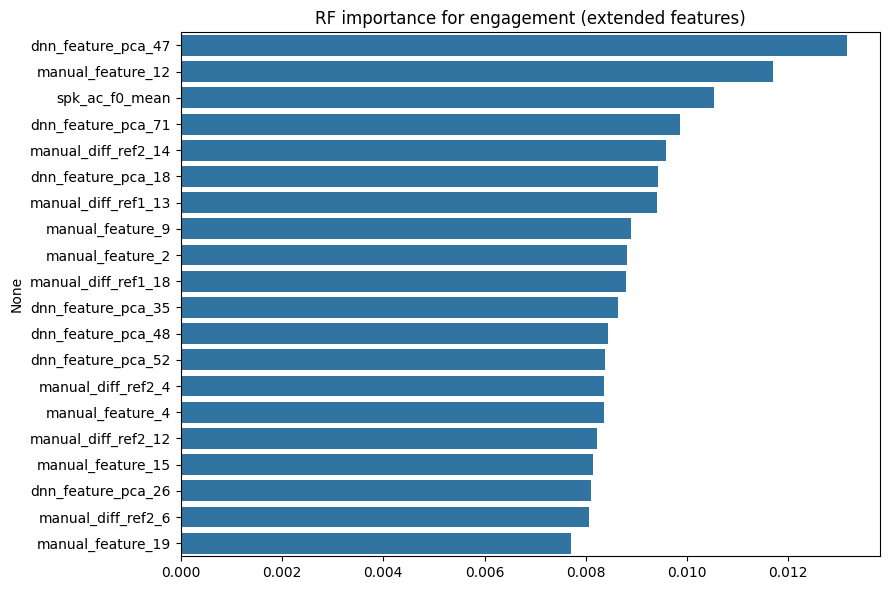

/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [145 157 162 163 197 209 214 215 243 260 261 289 306 307] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/ducanh/miniconda3/envs/thesis2/lib/python3.10/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


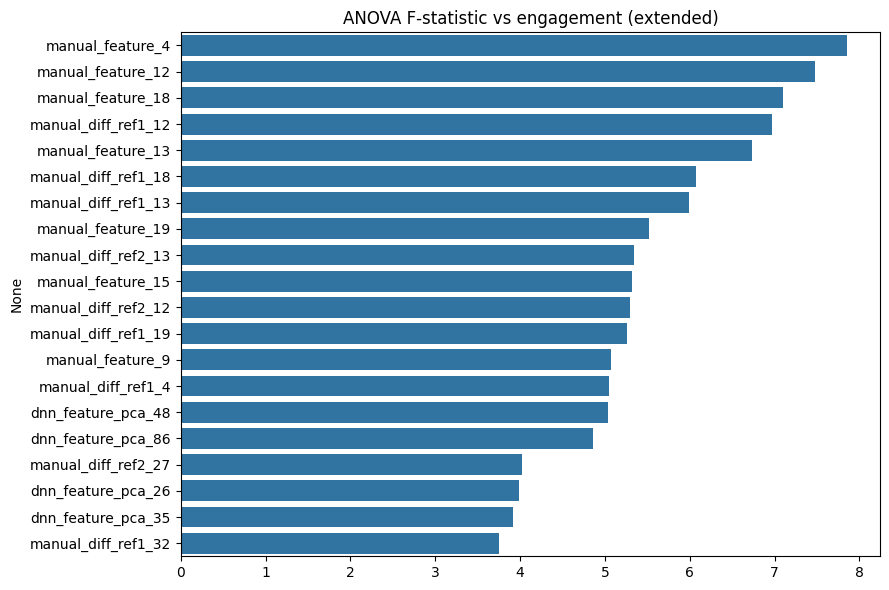

Speaker-feature ranks within RF importance (1 = most important):
  #  3  spk_ac_f0_mean
  # 28  spk_txt_words_per_sec
  # 36  spk_ac_final_rise_st
  # 57  spk_ac_f0_std_st
  # 65  spk_ac_f0_slope_st
  # 79  spk_ac_jitter
  # 90  spk_ac_intensity_slope
  #105  spk_ac_pause_ratio
  #119  spk_ctx_meeting_position
  #123  spk_txt_sent_compound
  #130  spk_ctx_speaker_lead_sec
  #137  spk_ac_articulation_rate
  #147  spk_ac_shimmer
  #157  spk_ac_intensity_mean
  #169  speaker_overlap_sec
  #173  spk_txt_word_count
  #187  spk_ac_f0_curv
  #198  spk_ac_pitch_rise_rate
  #203  spk_ac_hnr
  #206  spk_ac_intensity_peak_count
  #209  spk_ac_pitch_rise_count
  #211  spk_ac_voiced_rate
  #216  spk_ac_pitch_fall_count
  #218  spk_txt_negation_rate
  #220  spk_txt_second_person_rate
  #224  spk_ac_accent_count
  #231  spk_txt_first_plural_rate
  #234  spk_txt_filler_rate
  #243  spk_ac_pause_count
  #248  spk_txt_backchannel_count
  #253  spk_txt_backchannel_rate
  #279  spk_ctx_num_speakers
  #287

,spk_ac_f0_mean,spk_txt_words_per_sec,spk_ac_final_rise_st,spk_ac_f0_std_st,spk_ac_f0_slope_st,spk_ac_jitter,spk_ac_intensity_slope,spk_ac_pause_ratio
engagement,,,,,,,,
Active engagement,172.675,4.646,1.290,3.855,0.057,0.021,-3.339,0.540
Disengagement,167.357,4.775,-3.575,3.354,-0.806,0.021,12.808,0.519
Intermittent engagement,189.751,4.074,2.346,4.029,-0.001,0.019,6.527,0.502


In [23]:
from sklearn.feature_selection import f_classif

def plot_feature_importances(importances, names, title, top_n=20):
    s = pd.Series(importances, index=names).sort_values(ascending=False)
    plt.figure(figsize=(9, max(5, top_n*0.3)))
    sns.barplot(x=s.head(top_n).values, y=s.head(top_n).index)
    plt.title(title); plt.tight_layout(); plt.show()
    return s

# RandomForest importance for ENGAGEMENT (supervised on labels, extended features)
rf = RandomForestClassifier(n_estimators=400, random_state=42, class_weight='balanced')
rf.fit(StandardScaler().fit_transform(Xlab_ext), y)
imp = plot_feature_importances(rf.feature_importances_, Xlab_ext.columns.tolist(),
                               "RF importance for engagement (extended features)")

# ANOVA F-stat vs engagement
F, _ = f_classif(Xlab_ext.fillna(0), y)
anova = plot_feature_importances(np.nan_to_num(F), Xlab_ext.columns.tolist(),
                                 "ANOVA F-statistic vs engagement (extended)")

# How highly do speaker features rank?
spk_mask = imp.index.str.startswith('spk_') | (imp.index == 'speaker_overlap_sec')
ranks = {f: int(np.where(imp.index == f)[0][0]) + 1 for f in imp.index[spk_mask]}
print("Speaker-feature ranks within RF importance (1 = most important):")
for f, r in sorted(ranks.items(), key=lambda kv: kv[1]):
    print(f"  #{r:3d}  {f}")

# Mean of the most-important speaker features per engagement label (chosen dynamically)
print("\nMean speaker features by engagement label:")
key_spk = [f for f in imp.index[spk_mask]][:8]
summary = Xlab_ext.assign(engagement=y).groupby('engagement')[key_spk].mean()
import IPython.display as _d; _d.display(summary.round(3))

## Findings (v5 — compact encoding rehabilitates alignment + speaker; `manual_diff` was the culprit)

**Headline.** With a genuine **target-only** baseline and a leakage-free 5-fold supervised CV, the original
full feature set looked useless — but that was a **dimensionality artifact**. Dropping the high-dim
`manual_diff_*` block and keeping a *compact* encoding, behavioral **alignment** (6 AU/CLIP cosine sims) and
**speaker** prosody are **complementary** and jointly beat the target-only baseline.

| config | RF macro-F1 | RF acc | LR macro-F1\* | dim |
|---|---|---|---|---|
| baseline (target-only) | 0.341 ± 0.117 | 0.459 | 0.438 | 166 |
| + cosine-align (6 scalars) | 0.326 ± 0.094 | 0.482 | 0.474 | 172 |
| + speaker (no manual_diff) | 0.306 ± 0.073 | 0.483 | 0.392 | 203 |
| **+ cosine-align + speaker** | **0.364 ± 0.115** | **0.517** | 0.395 | 209 |
| + full alignment (+manual_diff) | 0.231 ± 0.075 | 0.415 | 0.381 | 310 |
| + full alignment + speaker | 0.295 ± 0.085 | 0.448 | 0.313 | 347 |
| majority-class floor | 0.220 | 0.494 | 0.220 | — |

\*LR fits raised divide-by-zero / overflow warnings (constant / degenerate one-hot columns), so LR numbers are
unreliable — **RandomForest is the primary estimator.**

**What this means.**
1. **The `manual_diff_*` block is the culprit, not the alignment concept.** Every config containing it collapses
   (RF 0.231 / 0.295); it adds ~138 element-wise-difference dims on only 89 samples — pure overfitting fuel. The
   earlier "alignment hurts" / "features don't help" conclusion was a dimensionality artifact.
2. **Alignment and speaker are complementary.** Each *alone* sits just below baseline (cosine-align 0.326,
   speaker 0.306), but **together they exceed it** (0.364) and post the best accuracy (0.517 vs 0.459). The two
   views carry non-redundant signal.
3. **Best config: target + 6 cosine-align scalars + speaker prosody (209-dim).** RF macro-F1 0.341 → 0.364 and
   accuracy 0.459 → 0.517 over the target-only baseline.
4. **Clustering still never recovers engagement** (KMeans k=3 ARI ≈ −0.01 to −0.03; see CV cell).

**Honest caveat (sample size).** The macro-F1 gain (+0.023) is **within the ±0.11 fold std** — on macro-F1 alone
this is "does not hurt / mild." The **accuracy gain (0.459 → 0.517) is more consistent** (std ≈ 0.07), which
strengthens it, but ~89 labels cap any firm claim. More labels is the highest-value next step.

**What survives as an interpretable marker: terminal intonation.**
`spk_ac_f0_mean` ranks **#3 of 347** in RF importance; `final_rise_st` mean by engagement — Active **+1.29**,
Intermittent **+2.35**, Disengaged **−3.58**. Disengaged listeners are addressed with *falling / flat* intonation;
engaged listeners with *rising* intonation. `f0_mean`: Intermittent 189.8 > Active 172.7 > Disengaged 167.4 Hz.

**Takeaways for the paper.**
1. The defensible, positive-but-careful claim: *with a compact encoding, behavioral alignment and speaker prosody
   are complementary and jointly improve listener-engagement prediction over a target-only nonverbal baseline; the
   full feature set's apparent failure was caused by a high-dimensional difference encoding, not absence of signal.*
2. **Report macro-F1 + accuracy + the majority-class floor + per-class** — never weighted-F1 alone (it rewards the
   majority *Active* class and masks the collapse).
3. **Drop `manual_diff_*`; keep the 6 cosine-similarity alignment scalars + speaker prosody.**
4. Largest remaining lever is **more labels** (±0.11 baseline std swamps the deltas).
